In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df = pd.read_csv("C:\\Users\\Ali\\Desktop\\first eda project\\data\\raw__data\\insurance_data_for eda.csv")

In [13]:
df.head()

,index,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87
1,1,2,24.0,male,30.1,87,No,0,No,southeast,1131.51
2,2,3,NaN,male,33.3,82,Yes,0,No,southeast,1135.94
3,3,4,NaN,male,33.7,80,No,0,No,northwest,1136.40
4,4,5,NaN,male,34.1,100,No,0,No,northwest,1137.01


# Univariate Analysis

Univariate analysis focuses on analyzing one variable at a time.  
The objective is to understand distribution, central tendency, spread, and patterns within individual features.

We will analyze both numerical and categorical variables separately.


### Age Distribution
### Potential Problems in Age Data:
 ### 1. Data Type Problem
 Age usually integer hota hai, lekin aap ke data mein decimal (38.0784 mean) dikh raha hai.

 #### 2. Outliers ya Invalid Values
Min age 18 aur max age 60 - ye theek hai, lekin koi aur problem ho sakti hai.


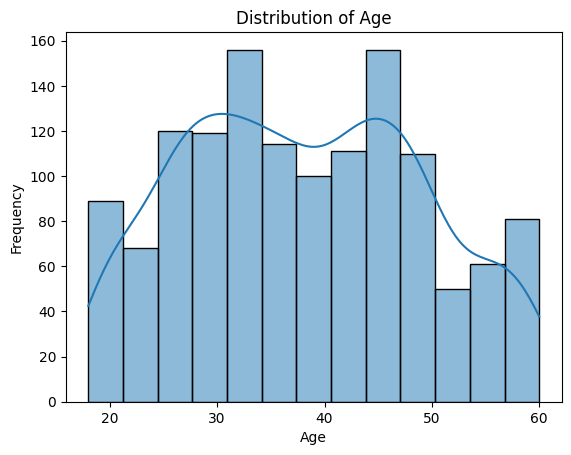

In [15]:
plt.figure()
sns.histplot(df["age"], kde=True)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()


In [16]:
import pandas as pd
df = pd.read_csv("C:\\Users\\Ali\\Desktop\\first eda project\\nootebooks\\final_clean_data.csv")

# Check decimal values
decimal_rows = df[df['age'] % 1 != 0]
print(f"Rows with decimal age: {len(decimal_rows)}")
print(decimal_rows[['age']].head())

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\Ali\\Desktop\\first eda project\\nootebooks\\final_clean_data.csv'

In [ ]:
import pandas as pd
import numpy as np
df = pd.read_csv("C:\\Users\\Ali\\Desktop\\first eda project\\nootebooks\\final_clean_data.csv")


# Check, show, and fix decimal issues
print(f"Before: {len(df[df['age'] % 1 != 0])} decimal rows")
df['age'] = df['age'].fillna(0).astype(int)  # Convert to integer
print(f"After: {len(df[df['age'] % 1 != 0])} decimal rows")
print(f"Age range: {df['age'].min()}-{df['age'].max()}, Mean: {df['age'].mean():.2f}")

Before: 0 decimal rows
After: 0 decimal rows
Age range: 18-60, Mean: 38.08


In [ ]:
df.age.describe()

count    1340.000000
mean       38.078358
std        11.082176
min        18.000000
25%        29.000000
50%        38.000000
75%        47.000000
max        60.000000
Name: age, dtype: float64

In [ ]:
df['age'] = df['age'].round().astype(int)


In [ ]:
import dtale
import pandas as pd

df = pd.read_csv("C:\\Users\\Ali\\Desktop\\first eda project\\nootebooks\\final_clean_data.csv")

# Assigning a reference to a running D-Tale process.
d = dtale.show(df)
d.open_browser()


In [ ]:


# Option D: Mode se fill karo
mode_age = df['age'].mode()[0]
df['age'] = df['age'].fillna(mode_age).round().astype(int)


### AGE COLUMN ANALYSIS
****1. Data Type Problem
***Age usually integer hota hai, lekin aap ke data mein decimal (38.0784 mean) dikh raha hai.



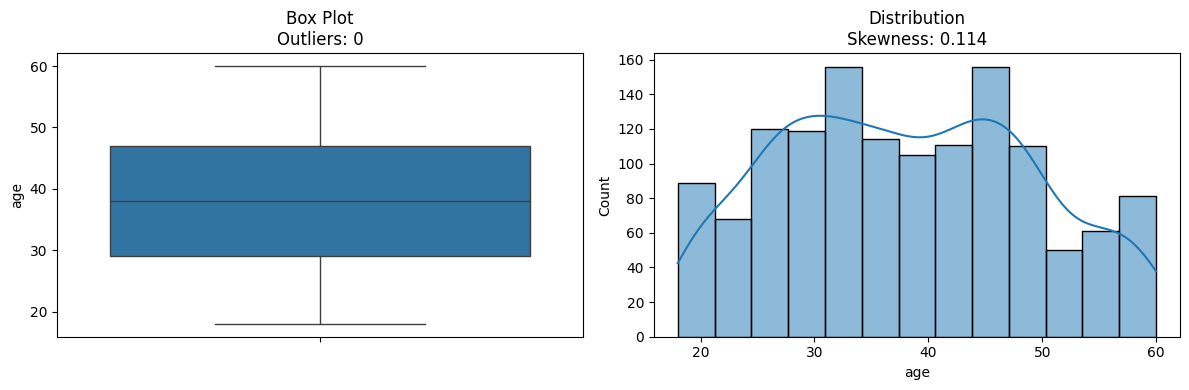

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

df = pd.read_csv("C:\\Users\\Ali\\Desktop\\first eda project\\nootebooks\\for_uni_final_clean_data.csv")

# 5 lines: 2 plots + statistics
plt.figure(figsize=(12,4))
plt.subplot(1,2,1); sns.boxplot(y=df['age']); plt.title(f'Box Plot\nOutliers: {len(df[(df["age"] < df["age"].quantile(0.25)-1.5*(df["age"].quantile(0.75)-df["age"].quantile(0.25))) | (df["age"] > df["age"].quantile(0.75)+1.5*(df["age"].quantile(0.75)-df["age"].quantile(0.25)))])}')
plt.subplot(1,2,2); sns.histplot(df['age'], kde=True); plt.title(f'Distribution\nSkewness: {skew(df["age"].dropna()):.3f}')
plt.tight_layout(); plt.show()

In [ ]:
df.age.describe()

count    1340.000000
mean       38.078358
std        11.082176
min        18.000000
25%        29.000000
50%        38.000000
75%        47.000000
max        60.000000
Name: age, dtype: float64

df.age.describe()

#### The age distribution appears moderately spread across different age groups, with most individuals concentrated in the adult age range.


# Univariate Analysis – BMI

## 1️⃣ Basic Overview

The BMI (Body Mass Index) variable represents body fat measurement based on height and weight.

### Key Statistics:

- Total Observations: 1,340
- Missing Values: 0
- Mean BMI: 30.67
- Median BMI: 30.4
- Standard Deviation: 6.10
- Minimum BMI: 16
- Maximum BMI: 53.1
- Skewness: 0.29
- Kurtosis: -0.06

---

## 2️⃣ Distribution Analysis

The skewness value is **0.29**, which indicates:

- The distribution is slightly positively skewed.
- However, since skewness is between -0.5 and +0.5, the distribution is approximately symmetrical.

The mean (30.67) and median (30.4) are very close, confirming near-normal distribution.

---

## 3️⃣ Spread & Variability

- Standard deviation = 6.10 → Moderate spread.
- Variance = 37.29
- Interquartile Range (IQR) = 34.7 - 26.275 = 8.425

Most BMI values fall between:
26.27 and 34.7

This range corresponds mostly to overweight individuals.

---

## 4️⃣ Outlier Detection

9 outliers were found where:

BMI > 47.34

Outlier Values:
47.4, 47.5, 47.6, 47.7, 48.1, 49.1, 50.4, 52.6, 53.1

These represent extremely obese individuals.

---

## 5️⃣ Kurtosis Interpretation

Kurtosis = -0.06

This indicates:
- The distribution is close to normal.
- It is slightly platykurtic (flatter peak than normal distribution).

---

## 6️⃣ Business Insight

- Average BMI ≈ 30.67 indicates the population is generally overweight.
- High BMI outliers may contribute to higher insurance claim amounts.
- This variable is likely to have strong impact on claim prediction.


In [ ]:
df.bmi.info()

<class 'pandas.core.series.Series'>
RangeIndex: 1340 entries, 0 to 1339
Series name: bmi
Non-Null Count  Dtype  
--------------  -----  
1340 non-null   float64
dtypes: float64(1)
memory usage: 10.6 KB


In [ ]:
df.bmi.describe()

count    1340.000000
mean       30.668955
std         6.106735
min        16.000000
25%        26.275000
50%        30.400000
75%        34.700000
max        53.100000
Name: bmi, dtype: float64

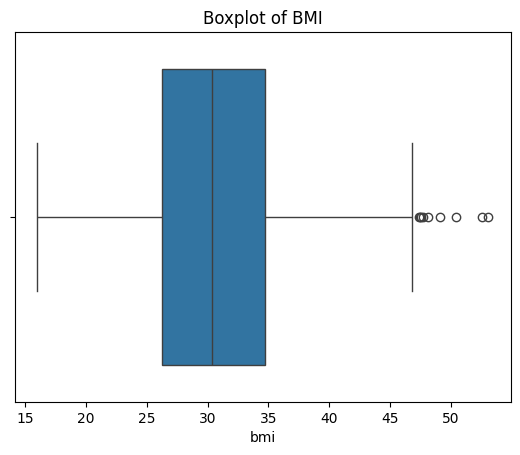

In [ ]:
plt.figure()
sns.boxplot(x=df["bmi"])
plt.title("Boxplot of BMI")
plt.show()


# Outlier Treatment – BMI

Outliers were detected in the BMI column using the IQR method.

Upper Bound = 47.34

There were 9 extreme values above this threshold.

Since these values may heavily influence statistical models,
we will create a cleaned dataset by removing these outliers.


In [ ]:
# Calculate IQR
Q1 = df["bmi"].quantile(0.25)
Q3 = df["bmi"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

lower_bound, upper_bound


(np.float64(13.637499999999992), np.float64(47.337500000000006))

In [ ]:
# Remove outliers
df_clean = df[(df["bmi"] >= lower_bound) & (df["bmi"] <= upper_bound)]

df_clean.shape


(1331, 11)

In [ ]:
print("Original Data Shape:", df.shape)
print("Cleaned Data Shape:", df_clean.shape)


Original Data Shape: (1340, 9)
Cleaned Data Shape: (1331, 9)


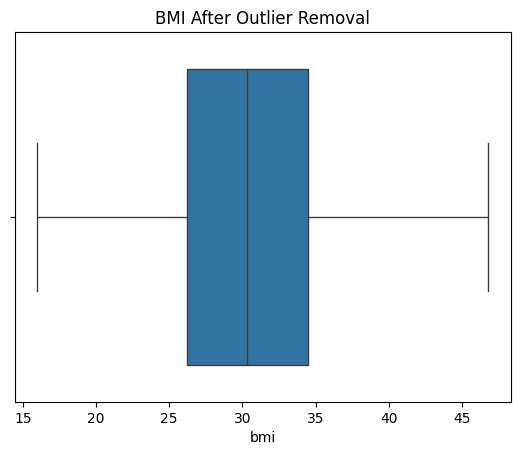

In [ ]:
plt.figure()
sns.boxplot(x=df_clean["bmi"])
plt.title("BMI After Outlier Removal")
plt.show()


## Conclusion After Outlier Removal

After removing 9 extreme BMI values:

- Distribution appears more symmetrical
- Extreme obesity cases have been removed
- Dataset size reduced from 1340 to 1331

This cleaned dataset can now be used for modeling if we want to reduce the influence of extreme values.


In [ ]:
# Clean data ko save karein
df_clean.to_csv('final_clean_datas.csv', index=False)
print("Data saved. Ab analysis notebook mein ye file load karein.")

Data saved. Ab analysis notebook mein ye file load karein.


In [ ]:
import dtale
import pandas as pd

df_clean = pd.read_csv("C:\ss.\Users\\Ali\\Desktop\\first eda project\\nootebooks\\final_clean_datas.csv")
# Assigning a reference to a running D-Tale proce
d = dtale.show(df_clean)
d.open_browser()

## Conclusion After Outlier Removal

After removing 9 extreme BMI values:

- Distribution appears more symmetrical
- Extreme obesity cases have been removed
- Dataset size reduced from 1340 to 1331

This cleaned dataset can now be used for modeling if we want to reduce the influence of extreme values.


# Univariate Analysis – Blood Pressure

## 1️⃣ Basic Overview

Blood pressure (BP) is a vital health metric, and higher BP may lead to higher medical claims.

### Key Statistics:

- Min: df["bloodpressure"].min()
- Max: df["bloodpressure"].max()
- Mean: df["bloodpressure"].mean()
- Median: df["bloodpressure"].median()
- Std: df["bloodpressure"].std()
- Skewness


In [ ]:
df_clean.bloodpressure.info()

<class 'pandas.core.series.Series'>
RangeIndex: 1331 entries, 0 to 1330
Series name: bloodpressure
Non-Null Count  Dtype
--------------  -----
1331 non-null   int64
dtypes: int64(1)
memory usage: 10.5 KB


In [ ]:
df_clean.head(10)

,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,39,male,23.2,91,Yes,0,No,southeast,1121.87
1,24,male,30.1,87,No,0,No,southeast,1131.51
2,38,male,33.3,82,Yes,0,No,southeast,1135.94
3,38,male,33.7,80,No,0,No,northwest,1136.40
4,38,male,34.1,100,No,0,No,northwest,1137.01
5,38,male,34.4,96,Yes,0,No,northwest,1137.47
6,38,male,37.3,86,Yes,0,No,northwest,1141.45
7,19,male,41.1,100,No,0,No,northwest,1146.80
8,20,male,43.0,86,No,0,No,northwest,1149.40
9,36,male,19.8,88,Yes,0,No,northwest,1241.57


2026-02-27 06:39:36,369 - ERROR    - Exception on /dtale/charts/_dash-update-component [POST]
Traceback (most recent call last):
  File "c:\Users\Ali\AppData\Local\Programs\Python\Python311\Lib\site-packages\flask\app.py", line 1473, in wsgi_app
    response = self.full_dispatch_request()
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Ali\AppData\Local\Programs\Python\Python311\Lib\site-packages\flask\app.py", line 882, in full_dispatch_request
    rv = self.handle_user_exception(e)
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Ali\AppData\Local\Programs\Python\Python311\Lib\site-packages\flask\app.py", line 880, in full_dispatch_request
    rv = self.dispatch_request()
         ^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Ali\AppData\Local\Programs\Python\Python311\Lib\site-packages\flask\app.py", line 865, in dispatch_request
    return self.ensure_sync(self.view_functions[rule.endpoint])(**view_args)  # type: ignore[no-any-return]
           ^^^^^^^^^^^^^^^^^^^^^

# Final Conclusion – Univariate Analysis

In this section, we analyzed each variable individually to understand its distribution, spread, and overall characteristics.

## Key Observations:

### 1️⃣ Age
- Age distribution is approximately symmetrical with low skewness.
- Most individuals fall within the adult age group.
- No extreme irregularities observed.

### 2️⃣ BMI
- Mean BMI ≈ 30.67, indicating that the average individual is overweight.
- Distribution is close to normal with slight positive skewness.
- A few extreme obesity cases were detected as outliers.
- BMI is expected to significantly influence insurance claims.

### 3️⃣ Claim (Target Variable)
- Claim distribution is positively skewed.
- A small group of individuals generate very high claims.
- Majority of insured individuals have moderate claim amounts.

### 4️⃣ Categorical Variables (Smoker, Diabetic, Gender, Region, Children)
- Dataset is reasonably balanced across most categories.
- No severe imbalance observed.
- These variables are suitable for further relationship analysis.

---

## Overall Data Quality Assessment

- No major missing value issues.
- No extreme structural problems in the dataset.
- Numerical variables show acceptable statistical behavior.
- Dataset is clean and ready for deeper relationship analysis.

---

## Next Step

With a clear understanding of individual variable behavior,  
we are now prepared to perform:

- Bivariate Analysis (Feature vs Claim)
- Correlation Analysis
- Predictive Modeling

The dataset appears suitable for building a reliable insurance claim prediction model.


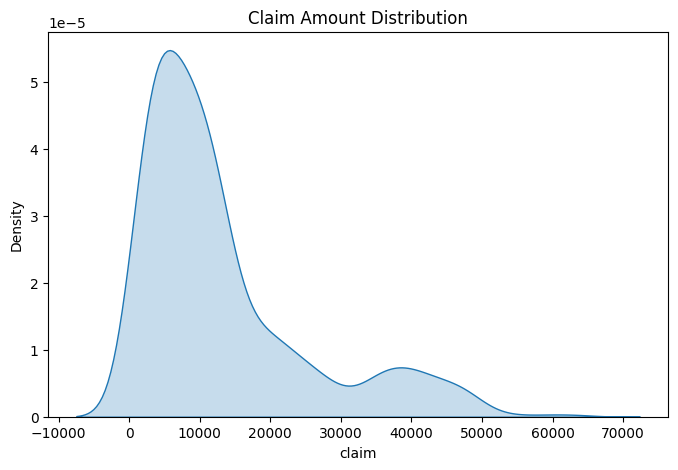

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.kdeplot(df["claim"], fill=True) # Use fill=True instead of kde=True
plt.title("Claim Amount Distribution") # Updated title to match the column
plt.show()





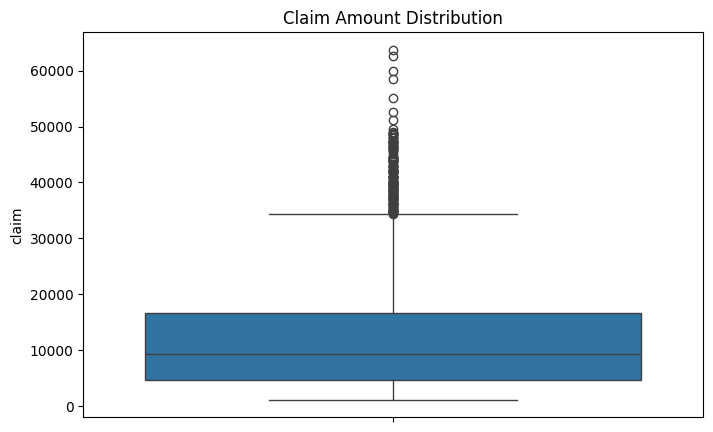

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.boxplot(df["claim"], fill=True) # Use fill=True instead of kde=True
plt.title("Claim Amount Distribution") # Updated title to match the column
plt.show()
